# Director Skill Sets Table 7 - Death dates only

In [1]:
import pandas_datareader.data as web #to collect data
import datetime as dt #to specify start and end dates

# import yfinance as yf

import eventstudy as es
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d
%matplotlib inline
import seaborn as sns

import scipy.stats as stats
from scipy.stats.mstats import winsorize
from scipy.spatial.distance import cdist


from sklearn.neighbors import NearestNeighbors

import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

from sklearn.preprocessing import StandardScaler

from patsy import dmatrices
from tqdm.notebook import tqdm
tqdm.pandas()

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] CAPM CAR\car_output4"
output_folder_path = "analysis_outputs"
# pca_input_folder_path = rf"..\..\..\[IN USE] Rookie Directors\[1.5] Director Skills PCA\director_skills_pca"
firm_input_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[2] Firm Level Wrangling\Firm level Iterative\Firm Lev + Fin\City level\city_lev_output"
filtering_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_filtering"
supporting_folder_path = "supporting_datafiles"

In [3]:
dirFirm00 = pd.read_pickle(rf"{import_folder_path}\Director Level_MF_CAR.pkl")
dirFirm00 = dirFirm00.loc[ dirFirm00["date_source"] == "Date of Demise"].reset_index(drop = True)

# pca = pd.read_pickle(rf"{pca_input_folder_path}\Main_Director_COMPLETE_PCA.pkl")
firm = pd.read_pickle(rf"{firm_input_folder_path}\Main_Firm_COMPLETE.pkl")

In [4]:
# pca_col = [
#     "Person Code", "AsOnDate", "Symbol",
#     "SkillsetIndex", "SkillsetGeneralistDummy",
#     "PC1_FactorScore", "PC1_FactorScore_Standardised"
# ]

# pca2 = pca[pca_col].copy()
# dirFirm00 = dirFirm0.merge(pca2, on = ["Person Code", "AsOnDate", "Symbol"], how = "left")

In [23]:
firm_col = [
    "AsOnDate", "Symbol",

    "PercentWomenDir", "PercentBusyDir",
    "LnBoardSize", "PercentIndep",
    "Promoters_percent", "NonpromoterInstitutions_percent", "RD to Assets",
    "ln_marcap", "ln_rdtoassets", "Debt to equity ratio", # control variables
    
    "FamilyOwnedFamilyCeoChair25", "promoterholding25", "HasFamilyChairmanAndCEO",
]

firm2 = firm[firm_col].copy()
dirFirm = dirFirm00.merge(firm2, on = ["AsOnDate", "Symbol"], how = "left")

In [24]:
# dirFirm data wrangling if any:
dirFirm["Year of Study"] = [x.year for x in dirFirm["Date of Study"]]

dirFirm = dirFirm.drop_duplicates(subset = ["Person Code", "Company", "Date of Study"]).reset_index(drop = True)

dirFirm["ln_dirage"] = np.log(dirFirm["Age"] + 1).astype("float")
dirFirm["ln_directorships"] = np.log((dirFirm["CompCountCurrTotalAB"] - 1) + 1).astype("float")

In [25]:
dirFirm.replace([np.inf, -np.inf], pd.NA, inplace = True)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_24600\3673678293.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dirFirm.replace([np.inf, -np.inf], pd.NA, inplace = True)


# PSM

## Verifying and removing those rows with no control data points

In [8]:
# Sample constraints ---> govtdummy==0 & findummy==0 & asonyear>2012
# dirFirm.columns.to_list()

In [34]:
dirFirm["IsDualityChairmanMD"] = dirFirm["IsDualityChairmanMD"].astype(int)


dirFirm["NIC_1digit"] = dirFirm["NIC code"].dropna().apply(lambda x: x[0:1])
dirFirm["NIC_1digit"] = dirFirm["NIC_1digit"]

# dirFirm.loc[dirFirm["RD to Assets"] == 0, "ln_rdtoassets"] = 0

psmSample = dirFirm.loc[ (dirFirm["Year of Study"] >= 2013)
    & (dirFirm["govtdummy"] == 0) & (dirFirm["findummy"] == 0) ].copy()
#.dropna(subset = controlVars).dropna(subset = dependentVar).copy()

# psmSample["DummySum"] = psmSample["IsRookie"] + psmSample["IsNonRookie"]
psmSample["DummySumIndep"] = psmSample["IsRookieIndep"] + psmSample["IsNonRookieIndep"]

# psmSampleAll = psmSample.loc[ psmSample["DummySum"] == 1 ].reset_index(drop = True)
# psmSampleAll = psmSampleAll.loc[ ~psmSampleAll.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

psmSampleIndep = psmSample.loc[ psmSample["DummySumIndep"] == 1 ].reset_index(drop = True)
# psmSampleIndep = psmSampleIndep.loc[ ~psmSampleIndep.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

In [35]:
len(psmSampleIndep)

541

In [31]:
len(psmSample.loc[ psmSample["IsRookieIndep"] == 1 ].dropna(subset = "210CAR11"))

28

## CAR windsorization

       winsorised_120CAR3  nonwinsorised_120CAR3
count          301.000000             301.000000
mean            -0.003596              -0.003596
std              0.054653               0.054653
min             -0.237923              -0.237923
25%             -0.036323              -0.036323
50%             -0.006224              -0.006224
75%              0.026115               0.026115
max              0.215313               0.215313


Top values and their count:  nonwinsorised_120CAR3
0.101145    1
0.103298    1
0.103476    1
0.107487    1
0.121585    1
0.137130    1
0.160104    1
0.166476    1
0.167355    1
0.215313    1
Name: count, dtype: int64





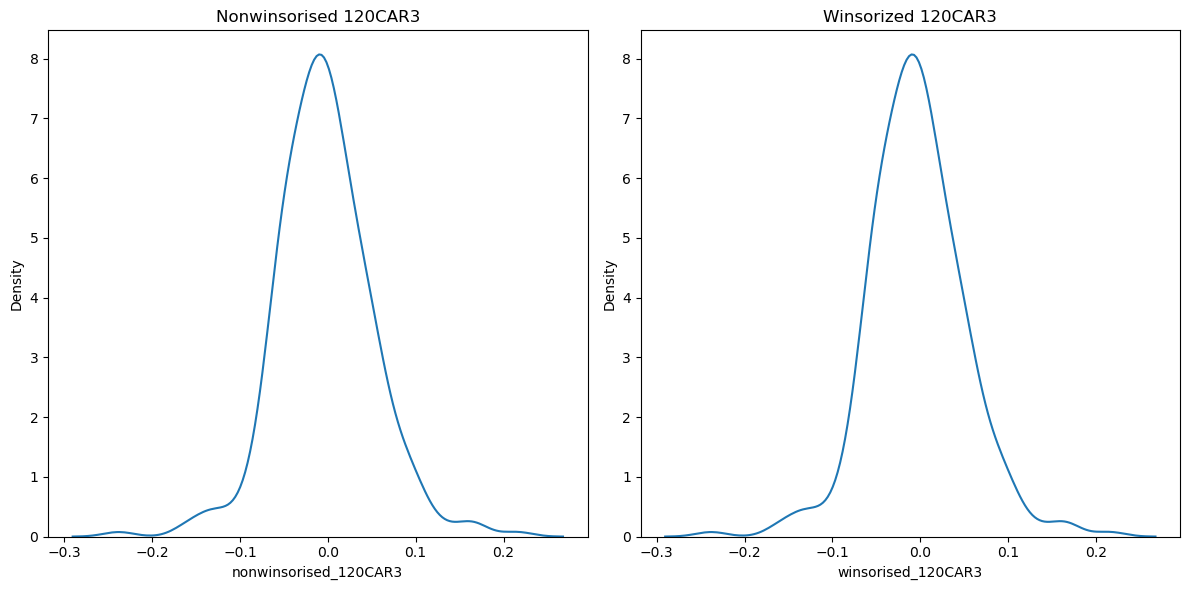

       winsorised_120CAR5  nonwinsorised_120CAR5
count          301.000000             301.000000
mean            -0.050938              -0.050938
std              0.070983               0.070983
min             -0.318701              -0.318701
25%             -0.086538              -0.086538
50%             -0.053074              -0.053074
75%             -0.016500              -0.016500
max              0.212517               0.212517


Top values and their count:  nonwinsorised_120CAR5
0.091408    1
0.092222    1
0.106260    1
0.107048    1
0.114758    1
0.119164    1
0.130520    1
0.141853    1
0.196030    1
0.212517    1
Name: count, dtype: int64





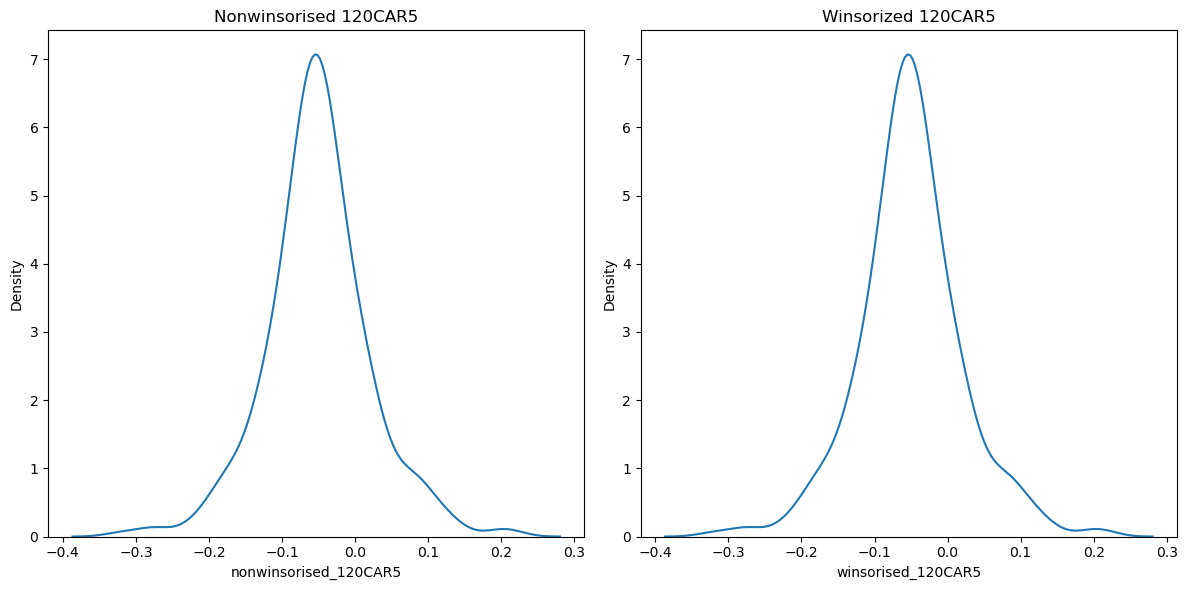

       winsorised_120CAR7  nonwinsorised_120CAR7
count          301.000000             301.000000
mean            -0.101450              -0.101450
std              0.095970               0.095970
min             -0.416580              -0.416580
25%             -0.153009              -0.153009
50%             -0.105162              -0.105162
75%             -0.055490              -0.055490
max              0.541790               0.541790


Top values and their count:  nonwinsorised_120CAR7
0.085283    1
0.086113    1
0.093562    1
0.103039    1
0.104947    1
0.105479    1
0.120722    1
0.122856    1
0.391124    1
0.541790    1
Name: count, dtype: int64





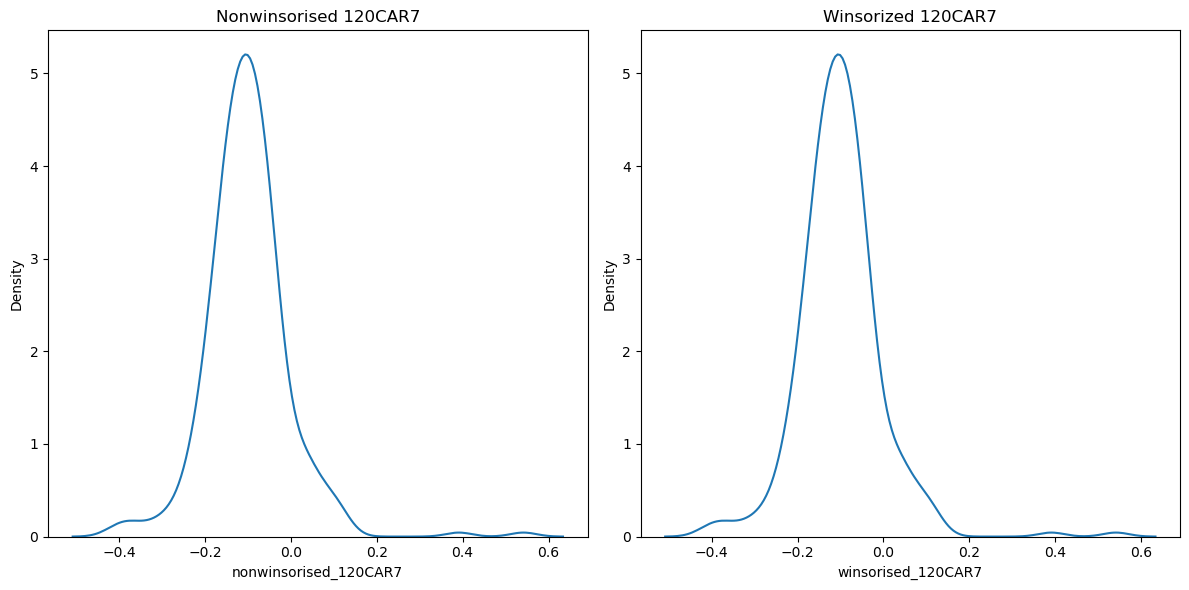

       winsorised_120CAR11  nonwinsorised_120CAR11
count           301.000000              301.000000
mean             -0.196858               -0.196858
std               0.126469                0.126469
min              -0.624257               -0.624257
25%              -0.269506               -0.269506
50%              -0.195160               -0.195160
75%              -0.124660               -0.124660
max               0.268643                0.268643


Top values and their count:  nonwinsorised_120CAR11
0.034597    1
0.071375    1
0.074439    1
0.088689    1
0.104092    1
0.111354    1
0.144658    1
0.212059    1
0.240275    1
0.268643    1
Name: count, dtype: int64





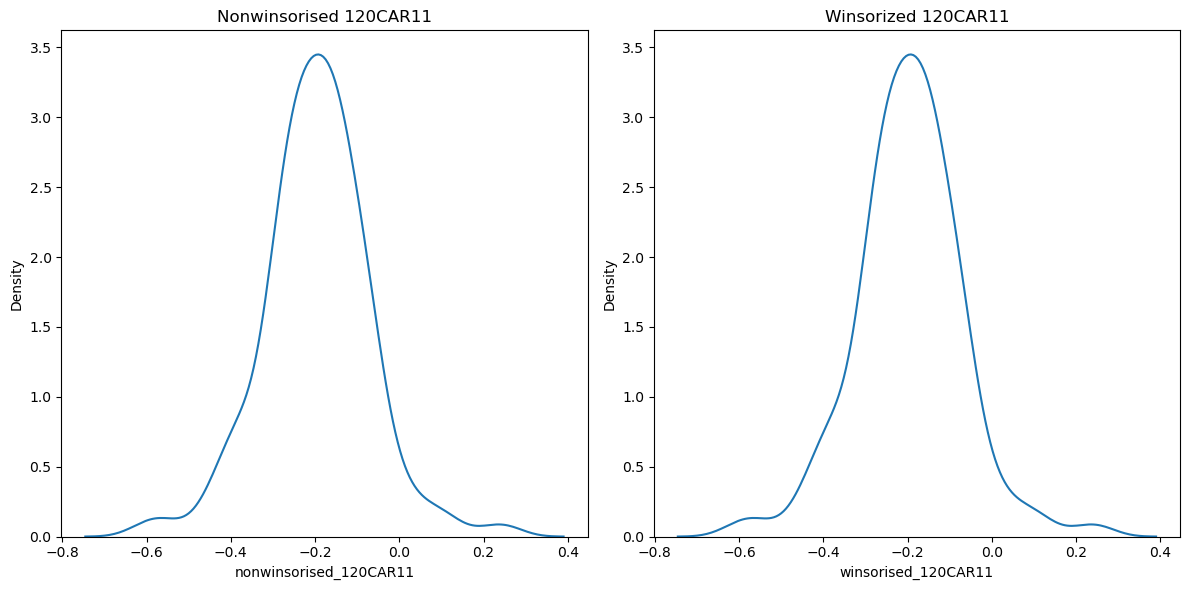

       winsorised_150CAR3  nonwinsorised_150CAR3
count          301.000000             301.000000
mean            -0.003708              -0.003708
std              0.054364               0.054364
min             -0.231427              -0.231427
25%             -0.038166              -0.038166
50%             -0.006075              -0.006075
75%              0.027337               0.027337
max              0.219026               0.219026


Top values and their count:  nonwinsorised_150CAR3
0.096628    1
0.100288    1
0.102454    1
0.108727    1
0.113018    1
0.135395    1
0.162234    1
0.164167    1
0.167139    1
0.219026    1
Name: count, dtype: int64





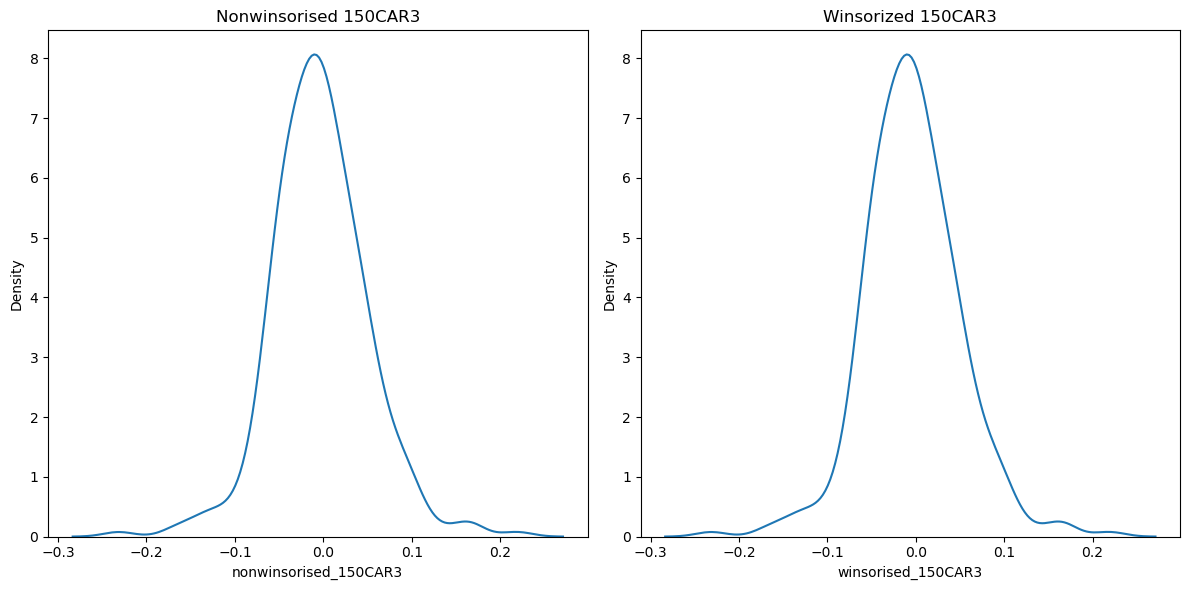

       winsorised_150CAR5  nonwinsorised_150CAR5
count          301.000000             301.000000
mean            -0.050914              -0.050914
std              0.070469               0.070469
min             -0.314709              -0.314709
25%             -0.085914              -0.085914
50%             -0.053073              -0.053073
75%             -0.016055              -0.016055
max              0.209175               0.209175


Top values and their count:  nonwinsorised_150CAR5
0.089079    1
0.093607    1
0.106404    1
0.107362    1
0.109173    1
0.116026    1
0.121178    1
0.140368    1
0.198402    1
0.209175    1
Name: count, dtype: int64





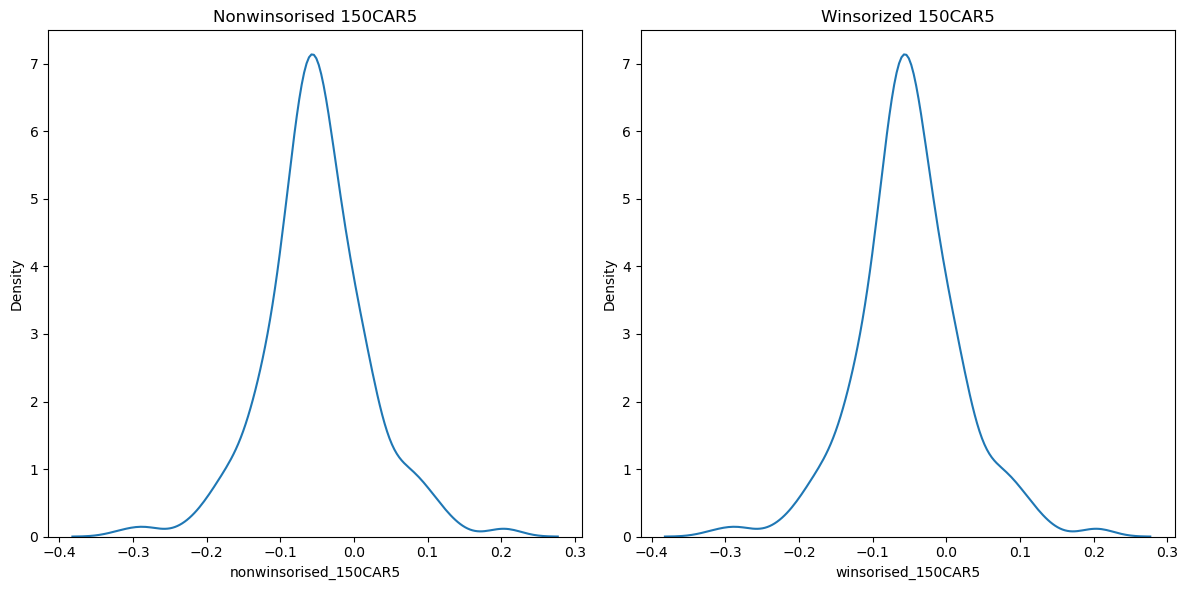

       winsorised_150CAR7  nonwinsorised_150CAR7
count          301.000000             301.000000
mean            -0.101350              -0.101350
std              0.095527               0.095527
min             -0.416627              -0.416627
25%             -0.152444              -0.152444
50%             -0.102943              -0.102943
75%             -0.055865              -0.055865
max              0.530379               0.530379


Top values and their count:  nonwinsorised_150CAR7
0.078290    1
0.089907    1
0.098789    1
0.101852    1
0.103785    1
0.106790    1
0.115710    1
0.120132    1
0.397046    1
0.530379    1
Name: count, dtype: int64





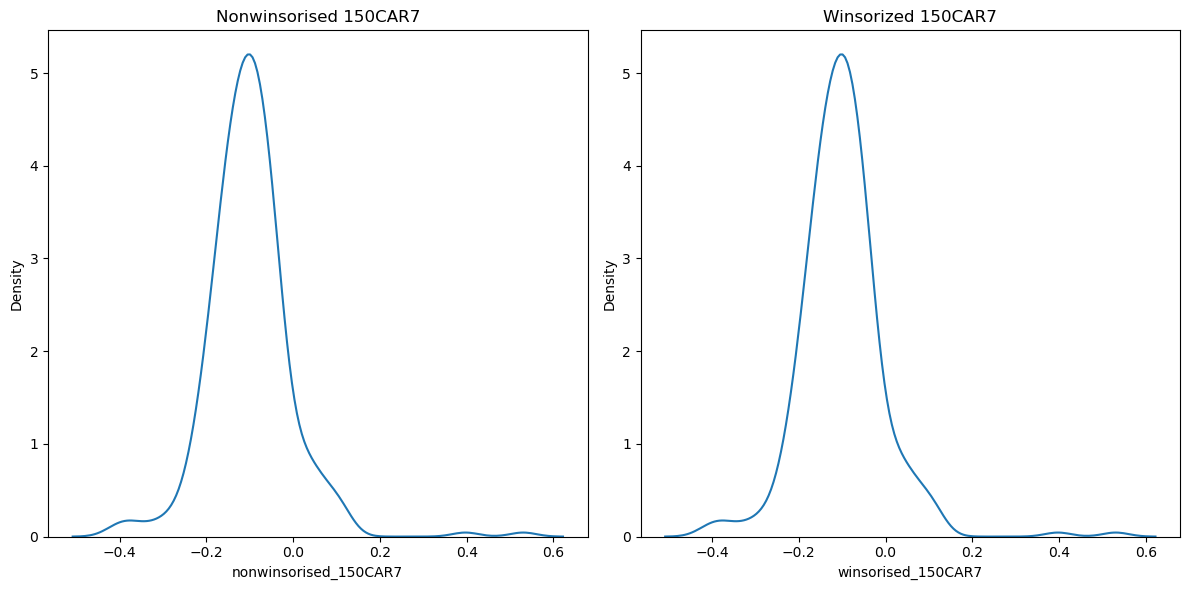

       winsorised_150CAR11  nonwinsorised_150CAR11
count           301.000000              301.000000
mean             -0.196817               -0.196817
std               0.126129                0.126129
min              -0.633743               -0.633743
25%              -0.272110               -0.272110
50%              -0.195831               -0.195831
75%              -0.125176               -0.125176
max               0.258974                0.258974


Top values and their count:  nonwinsorised_150CAR11
0.036767    1
0.051508    1
0.072645    1
0.100061    1
0.100707    1
0.103161    1
0.148668    1
0.220097    1
0.244827    1
0.258974    1
Name: count, dtype: int64





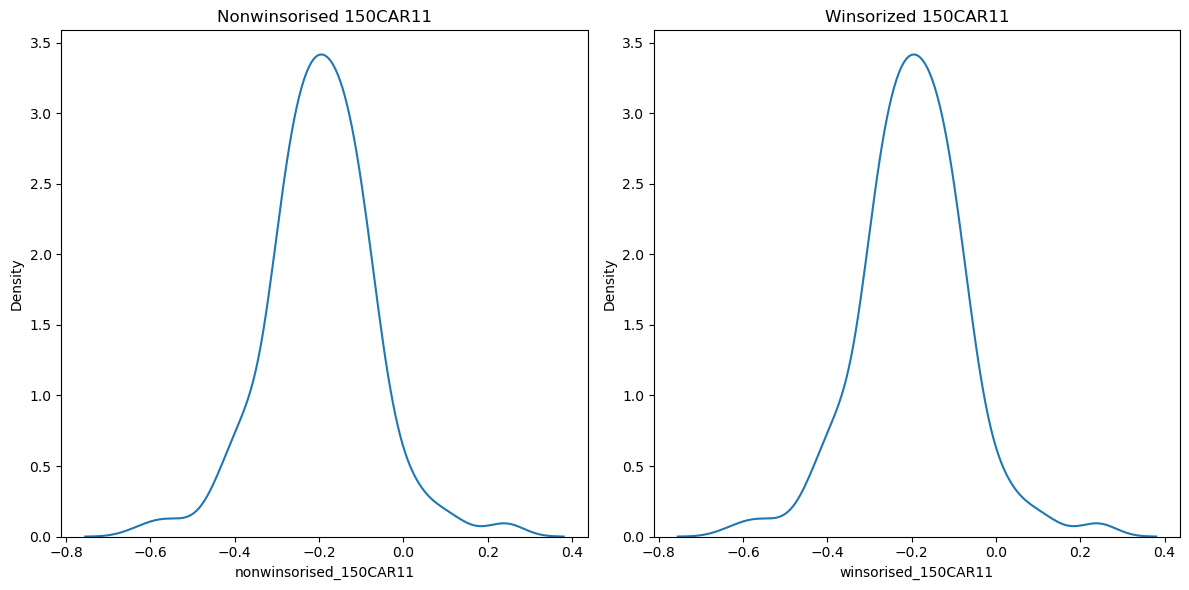

       winsorised_180CAR3  nonwinsorised_180CAR3
count          301.000000             301.000000
mean            -0.003349              -0.003349
std              0.054167               0.054167
min             -0.231893              -0.231893
25%             -0.038306              -0.038306
50%             -0.006629              -0.006629
75%              0.028290               0.028290
max              0.218510               0.218510


Top values and their count:  nonwinsorised_180CAR3
0.097271    1
0.103241    1
0.103363    1
0.109538    1
0.109687    1
0.138364    1
0.164057    1
0.169916    1
0.170428    1
0.218510    1
Name: count, dtype: int64





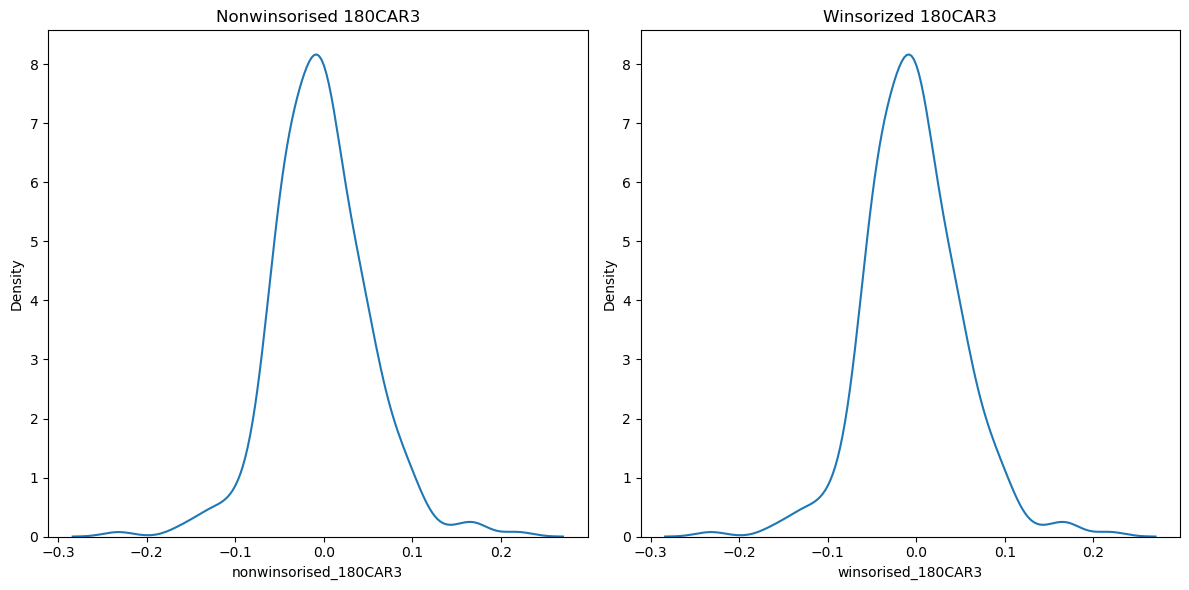

       winsorised_180CAR5  nonwinsorised_180CAR5
count          301.000000             301.000000
mean            -0.050646              -0.050646
std              0.070106               0.070106
min             -0.309244              -0.309244
25%             -0.085201              -0.085201
50%             -0.052843              -0.052843
75%             -0.015381              -0.015381
max              0.214968               0.214968


Top values and their count:  nonwinsorised_180CAR5
0.089599    1
0.090567    1
0.101892    1
0.108749    1
0.111000    1
0.116213    1
0.116245    1
0.144753    1
0.197642    1
0.214968    1
Name: count, dtype: int64





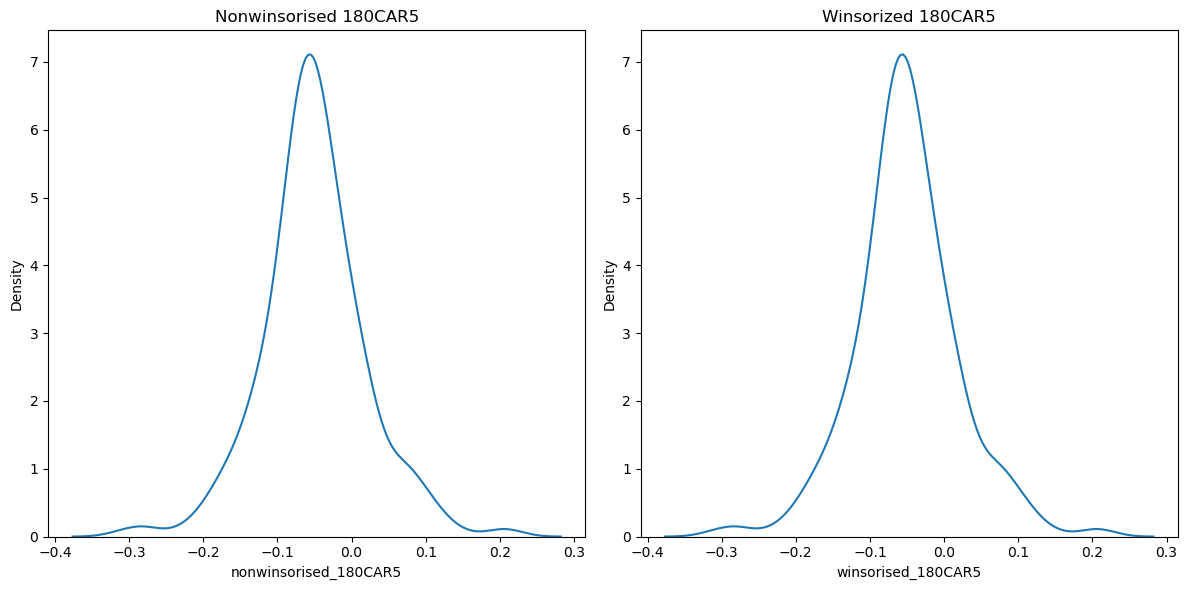

       winsorised_180CAR7  nonwinsorised_180CAR7
count          301.000000             301.000000
mean            -0.101138              -0.101138
std              0.095516               0.095516
min             -0.425623              -0.425623
25%             -0.151998              -0.151998
50%             -0.101783              -0.101783
75%             -0.057011              -0.057011
max              0.526327               0.526327


Top values and their count:  nonwinsorised_180CAR7
0.077703    1
0.093384    1
0.107606    1
0.107727    1
0.108807    1
0.109345    1
0.109513    1
0.120569    1
0.391820    1
0.526327    1
Name: count, dtype: int64





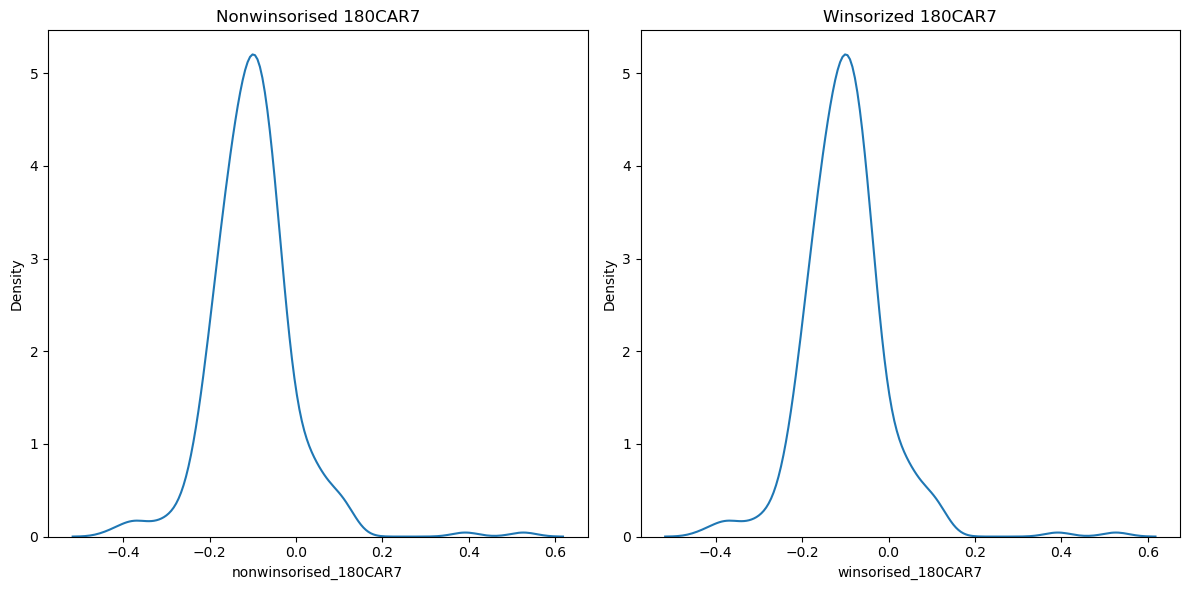

       winsorised_180CAR11  nonwinsorised_180CAR11
count           301.000000              301.000000
mean             -0.196380               -0.196380
std               0.126306                0.126306
min              -0.627395               -0.627395
25%              -0.269527               -0.269527
50%              -0.196213               -0.196213
75%              -0.122990               -0.122990
max               0.255310                0.255310


Top values and their count:  nonwinsorised_180CAR11
0.040585    1
0.054757    1
0.062172    1
0.096331    1
0.106052    1
0.121920    1
0.151251    1
0.230155    1
0.238879    1
0.255310    1
Name: count, dtype: int64





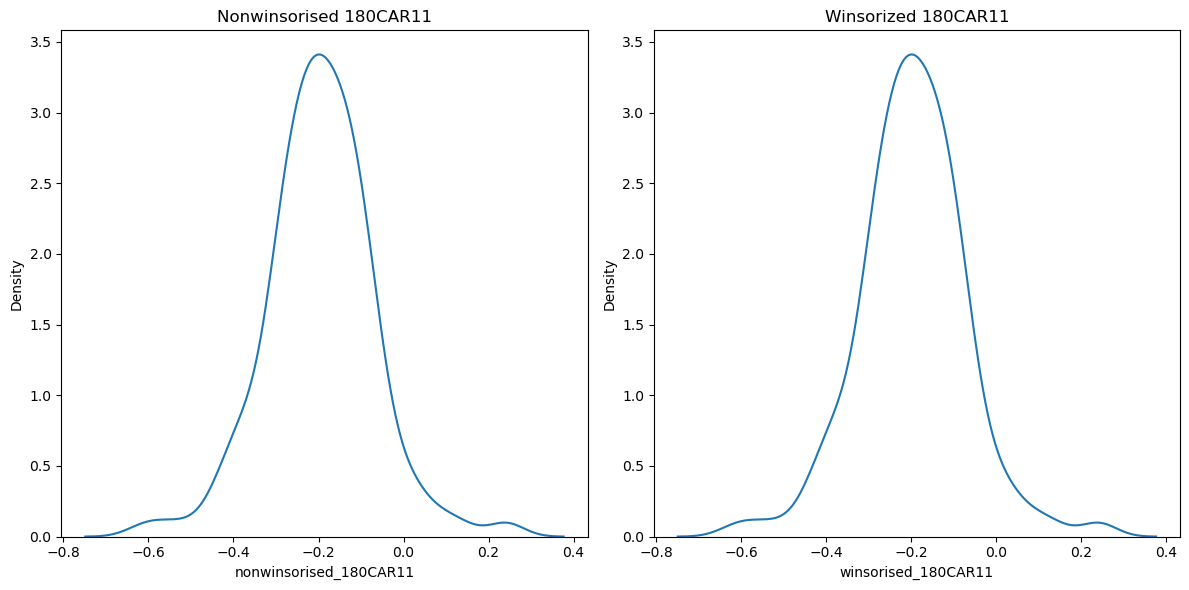

       winsorised_210CAR3  nonwinsorised_210CAR3
count          300.000000             300.000000
mean            -0.003465              -0.003465
std              0.053899               0.053899
min             -0.244071              -0.244071
25%             -0.037708              -0.037708
50%             -0.005396              -0.005396
75%              0.028568               0.028568
max              0.220388               0.220388


Top values and their count:  nonwinsorised_210CAR3
0.098786    1
0.101341    1
0.103245    1
0.107124    1
0.109870    1
0.136419    1
0.160335    1
0.162290    1
0.171668    1
0.220388    1
Name: count, dtype: int64





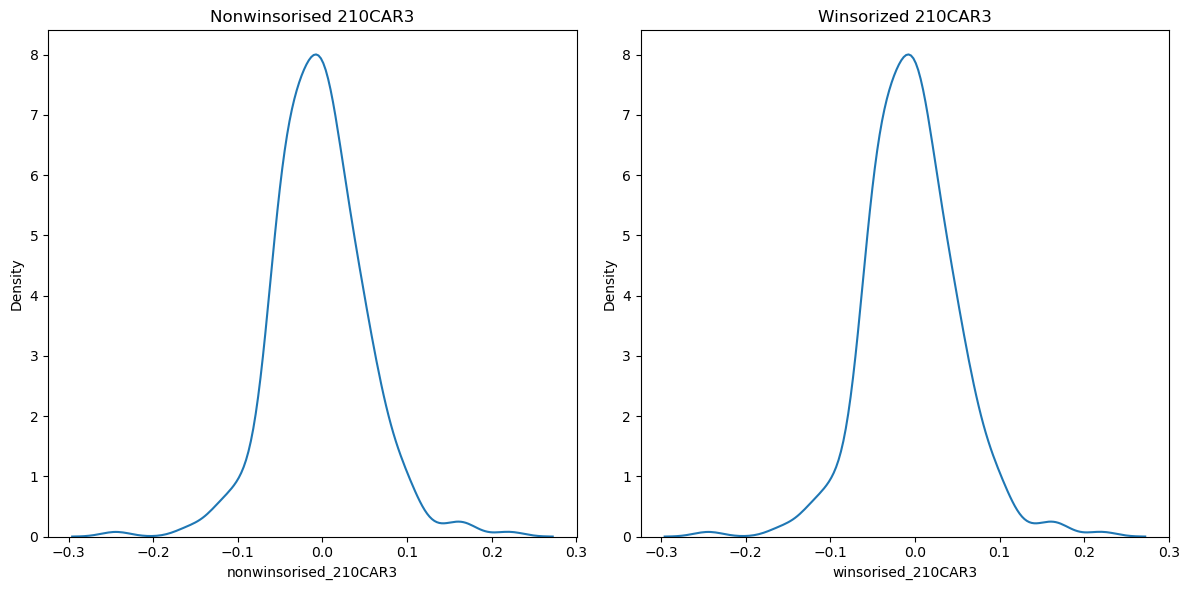

       winsorised_210CAR5  nonwinsorised_210CAR5
count          300.000000             300.000000
mean            -0.050770              -0.050770
std              0.069347               0.069347
min             -0.305161              -0.305161
25%             -0.085218              -0.085218
50%             -0.053126              -0.053126
75%             -0.014903              -0.014903
max              0.216647               0.216647


Top values and their count:  nonwinsorised_210CAR5
0.083372    1
0.092453    1
0.093809    1
0.100271    1
0.107280    1
0.114207    1
0.117053    1
0.136522    1
0.199461    1
0.216647    1
Name: count, dtype: int64





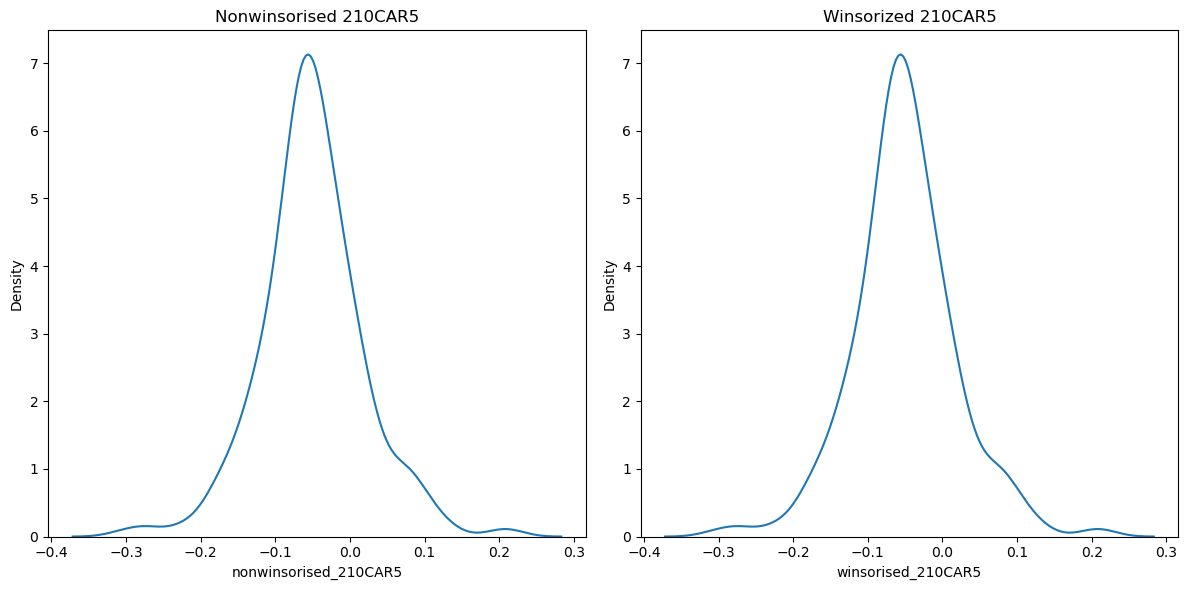

       winsorised_210CAR7  nonwinsorised_210CAR7
count          300.000000             300.000000
mean            -0.102378              -0.102378
std              0.091361               0.091361
min             -0.416962              -0.416962
25%             -0.154994              -0.154994
50%             -0.102689              -0.102689
75%             -0.054966              -0.054966
max              0.540097               0.540097


Top values and their count:  nonwinsorised_210CAR7
0.074246    1
0.079564    1
0.089334    1
0.104459    1
0.105215    1
0.106463    1
0.109270    1
0.112308    1
0.120787    1
0.540097    1
Name: count, dtype: int64





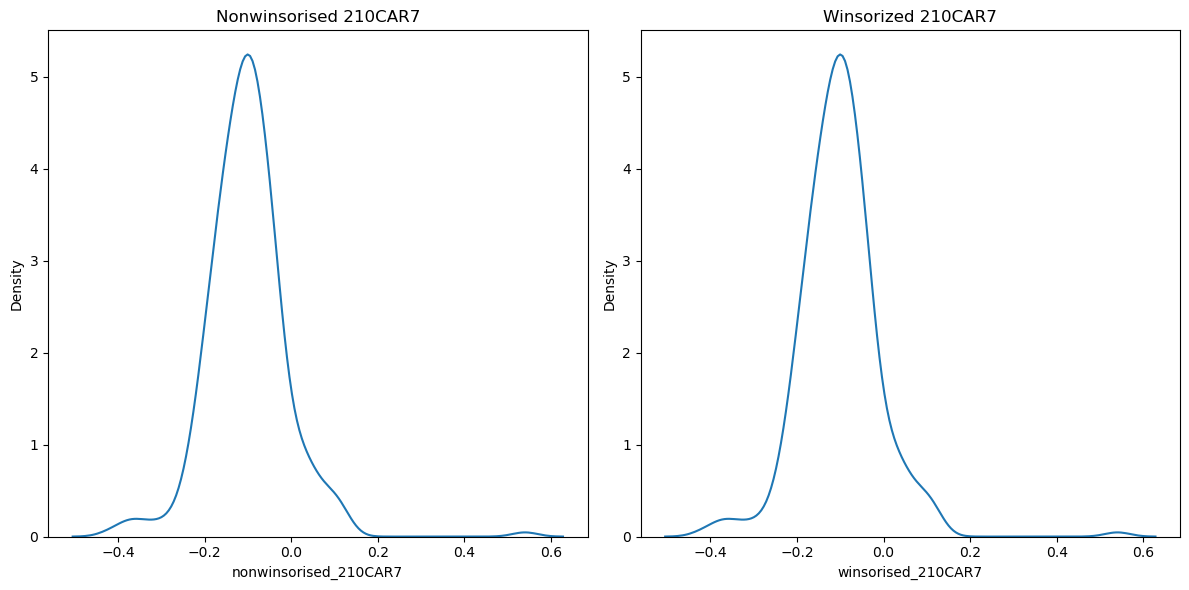

       winsorised_210CAR11  nonwinsorised_210CAR11
count           300.000000              300.000000
mean             -0.197692               -0.197692
std               0.123729                0.123729
min              -0.626474               -0.626474
25%              -0.266765               -0.266765
50%              -0.197309               -0.197309
75%              -0.120715               -0.120715
max               0.268893                0.268893


Top values and their count:  nonwinsorised_210CAR11
0.032907    1
0.046314    1
0.056357    1
0.061741    1
0.092791    1
0.107403    1
0.119170    1
0.147357    1
0.222628    1
0.268893    1
Name: count, dtype: int64





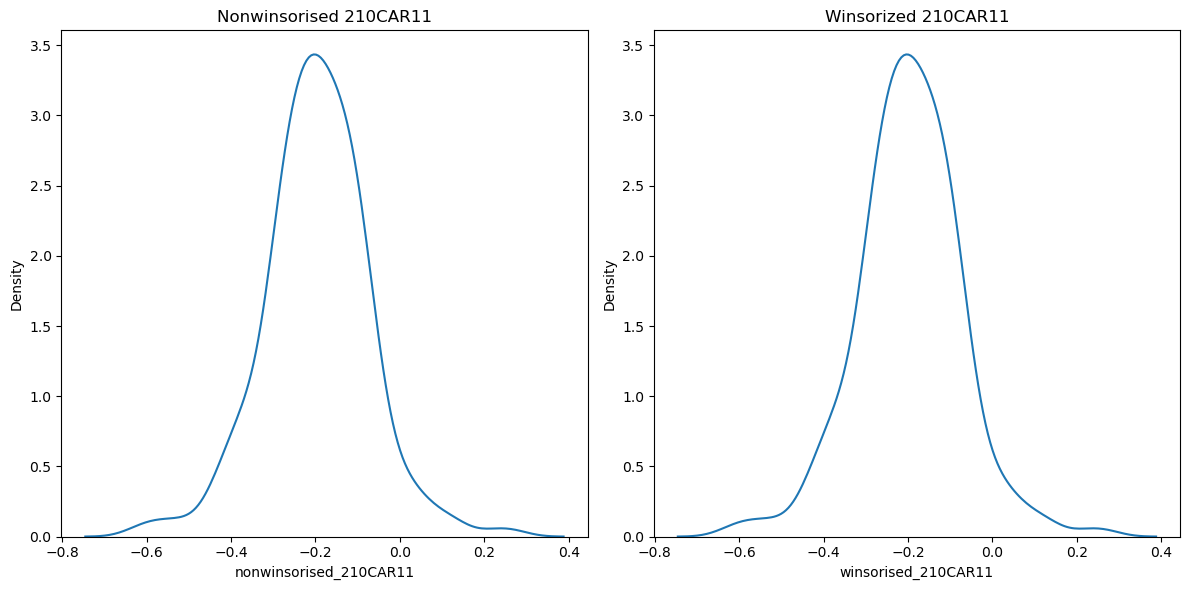

In [10]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    print("\n\nTop values and their count: ", (sample[f"nonwinsorised_{variable}"].value_counts().sort_index().tail(n=10)))
    print("\n\n")
    
    # Graphs
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

for car in carCol:
    psmSampleIndep[car] = winsorize_output(psmSampleIndep, car, [0, 0])

In [11]:
# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "PC1_FactorScore_Standardised", "ln_dirage", "ln_directorships"
# ]
# filter_datas = []
# CARs = [120, 150, 180, 210]
# for i,CAR in enumerate(CARs):
#     frame = pd. read_pickle(rf"{filtering_folder_path}\Insufficient Data for {CAR}CAR.pkl").rename({"AsOnDate":"Date"}, axis = 1)
#     filter_datas.append(frame)

# carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
#           "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
#           "180CAR3", "180CAR5", "180CAR7", "180CAR11",
#           "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

# print("N for each CAR, no subsampling, dropping for na in control vars + car")

# event_days = [3, 5, 7, 11]

# for i,CAR in enumerate(CARs):
#     frame = psmSampleIndep.merge(filter_datas[i], left_on = ["CompanyName", "Appointment Date"], right_on = ["CompanyName", "Date"], how = "left")
#     for days in event_days:
#         car = f"{CAR}CAR{days}"
#         print(f"{car} N = ", frame.dropna(subset = [car] + controlVars)["na_trading_days"].mean() )

# frame_filtered = frame.dropna(subset=[car] + controlVars)
# frame_filtered["index"] = frame_filtered.index
# frame_filtered.plot(kind="scatter", x="index", y="na_trading_days")

In [12]:
# dirFirm2 = dirFirm.copy()
# psmSampleIndep2 = psmSampleIndep.copy()

# listCol = [
#     "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
#     "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
#     "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
#     "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
#     "OtherFirstYearPCodeIndepExcl","OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
#     "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
# ]

# dirFirm2 = dirFirm2.drop(listCol, axis = 1)
# psmSampleIndep2 = psmSampleIndep2.drop(listCol, axis = 1)


# dirFirm2.to_csv("Main_Firm_PSM Ready_no filter v040425.csv")
# psmSampleIndep2.to_csv("Main_Firm_PSM Ready_filter-Indep_gov_fin v040425.csv")


# # # psmSampleAll --> 2101 rows 
# # psmSampleIndep --> 1561 rows 

## PSM --> RookieAppoints as Treatment, NonRookieAppoints as Control

In [13]:
def LogitReg(sample, endog_var, exog_var):
    
    # Logit Regression
    endog = sample[endog_var]
    exog = sample[exog_var]
    
    scaler = StandardScaler()
    exog_standardised = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns)

    exog_standardised = sm.add_constant(exog_standardised)
    
    log_reg = sm.Logit(endog, exog_standardised).fit()

    propensityScores = log_reg.predict(exog_standardised)
    
    return propensityScores

In [14]:
def MeanDiffTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    if depVar != None:
        dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
        colsAdd = []
        for i in range(-1, 4):
            if i != 0:
                colsAdd.append(f"AsOnYear_T+{i}")
                colsAdd.append(f"{depVar}T+{i}")
                if i>0 :
                    colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
        newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "float")
        sample = pd.concat([sample, newFrame], axis = 1)
        sample = sample.copy()
        
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
                                                              right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
        for i in range(1, 4):
            if i != 0:
                sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
        sample = sample.copy()
    
    group1 = sample.loc[ sample[endog_var] == 1].copy()
    group2 = sample.loc[ sample[endog_var] == 0].copy()
    
    t_stat, p_value = stats.ttest_ind(group1[car], group2[car], equal_var=False)  # Welch’s t-test (default)

    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Treated Mean:", group1[car].mean(), " Control Mean:", group2[car].mean(), " Diff:", group1[car].mean() - group2[car].mean())
    print("Treated Median:", group1[car].median(), " Control Median:", group2[car].median(), " Diff:", group1[car].median() - group2[car].median())
    print("Treated N:", len(group1[car]), "; Control N:", len(group2[car]))
    print("[treated unique = ", len(group1.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]",\
          "[control unique = ", len(group2.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]"
         )
    print("\n")

    # -----------------------------------------------------------------------------------------------------------------
    
    if exog_var != None:
        print("━"*120)
        print(f'{"Matching Variable":<40} {"Treatment":<20} {"Control":<20} {"SMD":<20}')
        print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
        print("-"*120)

        for var in exog_var:
            treatMean = group1[var].mean()
            controlMean = group2[var].mean()
            # p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
            smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
            print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {smd:<20.4f}')
    
        print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    if depVar != None:
        print(depVar, " across years:\n")
        for i in range(1,4):
            sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
        group1 = sample.loc[ sample[endog_var] == 1].copy()
        group2 = sample.loc[ sample[endog_var] == 0].copy()

        print("━"*150, "\n")
        print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
        print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
        print("─"*150, "\n")
    
        for i in range(1,4):
            t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
            treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
            controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
            diffMean = treatedMean - controlMean
    
            treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
            controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
            diffMedian = treatedMedian - controlMedian
    
            print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
            label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            label2 = "Control N: " + str(len(group2[depVar+f'(T+{i}) - (T-1)']))
            
            print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
            print("-"*150, "\n")
            
        print("━"*150, "\n")

    return

In [15]:
def OneSampleTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    # if depVar != None:
    #     dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
    #     colsAdd = []
    #     for i in range(-1, 4):
    #         if i != 0:
    #             colsAdd.append(f"AsOnYear_T+{i}")
    #             colsAdd.append(f"{depVar}T+{i}")
    #             if i>0 :
    #                 colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
    #     newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "int")
    #     sample = pd.concat([sample, newFrame], axis = 1)
    #     sample = sample.copy()
        
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
    #                                                           right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
    #     for i in range(1, 4):
    #         if i != 0:
    #             sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
    #     sample = sample.copy()
    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    group1 = sample.copy()
    
    t_stat, p_value = stats.ttest_1samp(group1[car], 0)  # Welch’s t-test (default)
    
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Mean:", group1[car].mean())
    print("Median:", group1[car].median())
    print("N:", len(group1[car]))

    print("\n")

    # -----------------------------------------------------------------------------------------------------------------




    # if exog_var != None:
    #     print("━"*120)
    #     print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
    #     print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
    #     print("-"*120)

    #     for var in exog_var:
    #         treatMean = group1[var].mean()
    #         controlMean = group2[var].mean()
    #         p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
    #         print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
    #     print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    # if depVar != None:
    #     print(depVar, " across years:\n")
    #     for i in range(1,4):
    #         sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
    #     group1 = sample.loc[ sample[endog_var] == 1].copy()
    #     group2 = sample.loc[ sample[endog_var] == 0].copy()

    #     print("━"*150, "\n")
    #     print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
    #     print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
    #     print("─"*150, "\n")
    
    #     for i in range(1,4):
    #         t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
    #         treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
    #         controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
    #         diffMean = treatedMean - controlMean
    
    #         treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
    #         controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
    #         diffMedian = treatedMedian - controlMedian
    
    #         print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
    #         label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
    #         label2 = "Control N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            
    #         print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
    #         print("-"*150, "\n")
            
    #print("━"*150, "\n")

    return

In [16]:
def PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    treated = sample.loc[ sample[endog_var] == 1].copy()
    control = sample.loc[ sample[endog_var] == 0].copy()

    # Nearest Neighbours
    nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean")
    nn.fit(control[["propensityScore"]])

    distances, indices = nn.kneighbors(treated[["propensityScore"]])
    
    matchedControl = control.iloc[indices.flatten()].copy()
    
    matched = pd.concat([treated, matchedControl])
    matched.reset_index(drop=True, inplace=True)

    MeanDiffTtest(matched, endog_var, exog_var, car, depVar, dirFirm)

    return

In [17]:
# Func PSM non replacement
def PsmNonReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    # Separate treated and control groups
    treated = sample[sample[endog_var] == 1].copy()
    control = sample[sample[endog_var] == 0].copy()
    
    # Compute pairwise distances (absolute difference in propensity scores)
    dist_matrix = cdist(treated[['propensityScore']], control[['propensityScore']], metric='euclidean')
    
    # Match without replacement
    treated_indices = []
    matched_indices = []
    used_control_indices = set()
    
    for i in range(len(treated)):
        if len(used_control_indices) >= len(control):  # Stop if no controls left
            print("Warning: Not enough control units to match all treated units.")
            break
        
        # Get nearest control unit index that hasn't been used
        match_idx = np.argmin(dist_matrix[i])
        
        while match_idx in used_control_indices:  # Ensure it's not already matched
            dist_matrix[i, match_idx] = np.inf  # Temporarily set distance to infinity

            if np.all(dist_matrix[i] == np.inf):  # If all controls are exhausted
                print(f"No available control for treated unit {i}, skipping.")
                match_idx = None
                break
            
            match_idx = np.argmin(dist_matrix[i])
        
        used_control_indices.add(match_idx)
        matched_indices.append(match_idx)
        treated_indices.append(i)
    
    # Retrieve matched units
    matched_control = control.iloc[matched_indices].copy()
    matched_treated = treated.iloc[treated_indices].copy()
    
    # Combine matched treated and control units
    matched_data = pd.concat([matched_treated.reset_index(drop=True), matched_control.reset_index(drop=True)])
    
    # Reset index
    matched_data.reset_index(drop=True, inplace=True)


    # Mean difference and T Test
    MeanDiffTtest(matched_data, endog_var, exog_var, car, depVar, dirFirm)

    return
    


In [18]:
def prep_sample(sample, car, controlVars, yearDummy = 0, industryDummy = 0) -> tuple[pd.DataFrame, list[str]]:
    
    sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)

    if yearDummy == 1:
        yearDummies = pd.get_dummies( sample["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = yearDummies.sum().loc[ yearDummies.sum() == 1 ].index.values
        yearDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, yearDummies], axis = 1)
    else:
        yearDummies = pd.DataFrame()
    
    if industryDummy == 1:
        industryDummies = pd.get_dummies( sample["NIC_1digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = industryDummies.sum().loc[ industryDummies.sum() == 1 ].index.values
        industryDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, industryDummies], axis = 1)
    else:
        industryDummies = pd.DataFrame()

    exog_var = controlVars + yearDummies.columns.to_list() + industryDummies.columns.to_list()

    # checking for multicollinearity
    if exog_var:
        from statsmodels.stats.outliers_influence import variance_inflation_factor
        
        from statsmodels.tools.tools import add_constant
        exog_with_const = add_constant(sample[exog_var])
        
        vif_data = pd.DataFrame()
        vif_data["feature"] = exog_with_const.columns
        vif_data["VIF"] = [variance_inflation_factor(exog_with_const.values, i)
                           for i in range(exog_with_const.shape[1])]
        highCollinearity = [x for x in 
                        vif_data.loc[ vif_data["VIF"] > 10 ]["feature"].values
                        if x!="const"]
        exog_var = [x for x in exog_var if x not in highCollinearity]    
    
    return sample, exog_var

# PSM on PCA output + other controls

In [19]:
controlVars = ["PercentWomenDir", "PercentBusyDir",
               "LnBoardSize", "PercentIndep",
               "Promoters_percent", "NonpromoterInstitutions_percent",
               "ln_marcap", "ln_rdtoassets", "Debt to equity ratio"]

controlVars = ["LnBoardSize"]
# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "Skilllist_FactorScore", "ln_dirage", "ln_directorships"
# ]

#PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm)

# No Higher level Filtration

## Version 0: No filtration

## No fixed effects

### PSM with replacement

In [20]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.316963
         Iterations 6


120CAR3 :


T Statistic: 1.3607143459266573  P Value: 0.18030870134031407
Treated Mean: 0.002091863033511835  Control Mean: -0.009968612669092042  Diff: 0.012060475702603877
Treated Median: -0.0037054096836927133  Control Median: -0.017349065888651004  Diff: 0.01364365620495829
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2386               -0.0205             
━━━━

In [21]:
len(sample.loc[ sample["IsRookieIndep"] == 1])


28

## Using Year fixed effects

### PSM with replacement

In [22]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.291022
         Iterations: 35


120CAR3 :


T Statistic: -2.1132264642475214  P Value: 0.040415646099080084
Treated Mean: 0.002091863033511835  Control Mean: 0.036005315641798465  Diff: -0.033913452608286626
Treated Median: -0.0037054096836927133  Control Median: 0.01406492131794121  Diff: -0.017770331001633922
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  22 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2347               -0.0104             
YearDummy__2014                       

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.291022
         Iterations: 35


120CAR7 :


T Statistic: -0.7653080904099983  P Value: 0.44747951361466953
Treated Mean: -0.10033661922160864  Control Mean: -0.07915210013659826  Diff: -0.021184519085010373
Treated Median: -0.11463211714898411  Control Median: -0.10587695619688364  Diff: -0.008755160952100466
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  22 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2347               -0.0104             
YearDummy__2014                         

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.291022
         Iterations: 35


150CAR3 :


T Statistic: -2.05984795082495  P Value: 0.04549394054673297
Treated Mean: 0.0026007603273354146  Control Mean: 0.03612612507642463  Diff: -0.033525364749089216
Treated Median: 0.006026959935070478  Control Median: 0.01817432683061232  Diff: -0.012147366895541842
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  22 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2347               -0.0104             
YearDummy__2014                          0.

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.286406
         Iterations: 35


210CAR5 :


T Statistic: -1.5564091726718445  P Value: 0.1265276805327638
Treated Mean: -0.054248482192493334  Control Mean: -0.020214990649475555  Diff: -0.03403349154301778
Treated Median: -0.059431146068591456  Control Median: -0.032272077265977445  Diff: -0.02715906880261401
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  22 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2765               -0.1293             
YearDummy__2014                        

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg



210CAR11 :


T Statistic: 0.02863406052560203  P Value: 0.9772622912622093
Treated Mean: -0.19275274947840484  Control Mean: -0.19358228768820407  Diff: 0.0008295382097992243
Treated Median: -0.17153555776724277  Control Median: -0.16844700222529213  Diff: -0.003088555541950644
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  22 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2765               -0.1293             
YearDummy__2014                          0.0714               0.1071               -0.1232             
Ye

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


## Using Year + Industry fixed effects

### PSM with replacement

In [23]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.279092
         Iterations: 35


120CAR3 :


T Statistic: -0.16473697636441326  P Value: 0.8697688460124965
Treated Mean: 0.002091863033511835  Control Mean: 0.004083360932796517  Diff: -0.0019914978992846824
Treated Median: -0.0037054096836927133  Control Median: 0.0007129234872447349  Diff: -0.004418333170937448
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  28 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2278               0.0083              
YearDummy__2014                     

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.279092
         Iterations: 35


120CAR5 :


T Statistic: 0.21778771967396784  P Value: 0.8284105152565937
Treated Mean: -0.04850633534916263  Control Mean: -0.05215651733921815  Diff: 0.003650181990055526
Treated Median: -0.05790322846814401  Control Median: -0.05204418468641474  Diff: -0.005859043781729273
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  28 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2278               0.0083              
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.279092
         Iterations: 35


120CAR7 :


T Statistic: -0.018452875547472238  P Value: 0.9853684195976984
Treated Mean: -0.10033661922160864  Control Mean: -0.09989071199691478  Diff: -0.00044590722469385613
Treated Median: -0.11463211714898411  Control Median: -0.10071552391699934  Diff: -0.01391659323198477
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  28 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2278               0.0083              
YearDummy__2014                       

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.272956
         Iterations: 35


210CAR7 :


T Statistic: -0.38332675400538035  P Value: 0.7029828524939205
Treated Mean: -0.11739640363959324  Control Mean: -0.11014269289818301  Diff: -0.007253710741410221
Treated Median: -0.1145366519759057  Control Median: -0.11252828376851892  Diff: -0.002008368207386785
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2638               -0.1009             
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.272956
         Iterations: 35


210CAR11 :


T Statistic: 0.27181713141751906  P Value: 0.7868536134479702
Treated Mean: -0.19275274947840484  Control Mean: -0.20003547054159818  Diff: 0.0072827210631933315
Treated Median: -0.17153555776724277  Control Median: -0.18944867961020975  Diff: 0.017913121842966978
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2638               -0.1009             
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


In [24]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [25]:
psmSampleIndep1 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [26]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.436381
         Iterations 6


120CAR3 :


T Statistic: 0.10249765951858861  P Value: 0.9190212362604171
Treated Mean: -0.0013784033505756478  Control Mean: -0.003182638699282142  Diff: 0.0018042353487064942
Treated Median: -0.012653449482477555  Control Median: -0.019605001428319842  Diff: 0.006951551945842287
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downc

Optimization terminated successfully.
         Current function value: 0.436381
         Iterations 6


120CAR5 :


T Statistic: 0.9873780703032843  P Value: 0.3300478965560064
Treated Mean: -0.03600633532280445  Control Mean: -0.0553202977734348  Diff: 0.01931396245063035
Treated Median: -0.04632420969961122  Control Median: -0.05204418468641474  Diff: 0.005719974986803517
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)


Optimization terminated successfully.
         Current function value: 0.436381
         Iterations 6


120CAR7 :


T Statistic: 1.2768811093669639  P Value: 0.21309180225544805
Treated Mean: -0.06679014704101963  Control Mean: -0.10687861209065713  Diff: 0.040088465049637506
Treated Median: -0.08430431238542566  Control Median: -0.10232941245923807  Diff: 0.018025100073812417
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downc



150CAR7 :


T Statistic: 1.314478313959932  P Value: 0.20042702800549522
Treated Mean: -0.06689399808216391  Control Mean: -0.10846149531733057  Diff: 0.04156749723516666
Treated Median: -0.08840094207947077  Control Median: -0.10528034648397916  Diff: 0.016879404404508386
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downc

Optimization terminated successfully.
         Current function value: 0.436381
         Iterations 6


180CAR11 :


T Statistic: 0.6057824675454756  P Value: 0.5487595805690844
Treated Mean: -0.14163375101559833  Control Mean: -0.16407003773648124  Diff: 0.02243628672088291
Treated Median: -0.14572982653718286  Control Median: -0.14252074060223957  Diff: -0.00320908593494329
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)


## Using Year fixed effects

### PSM with replacement

In [27]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: inf
         Iterations: 35


120CAR3 :


T Statistic: -1.2583487273935992  P Value: 0.21730772899179693
Treated Mean: -0.0013784033505756478  Control Mean: 0.019775312421987757  Diff: -0.021153715772563406
Treated Median: -0.012653449482477555  Control Median: 0.012962479815843503  Diff: -0.025615929298321058
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.0796               0.3793              
YearDummy__2014                          0

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihoo



120CAR5 :


T Statistic: 0.1585339945542341  P Value: 0.8749730005575431
Treated Mean: -0.03600633532280445  Control Mean: -0.03954977333144732  Diff: 0.003543438008642867
Treated Median: -0.04632420969961122  Control Median: -0.04382267710471735  Diff: -0.002501532594893871
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.0796               0.3793              
YearDummy__2014                          0.1053               0.2105               -0.2839             
YearD

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavi



150CAR3 :


T Statistic: -1.1499685235962616  P Value: 0.2586246947730529
Treated Mean: -0.0009951953570073845  Control Mean: 0.01865635772977739  Diff: -0.019651553086784776
Treated Median: -0.013925634785143234  Control Median: 0.014718415271334509  Diff: -0.028644050056477743
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.0796               0.3793              
YearDummy__2014                          0.1053               0.2105               -0.2839             
Y

...

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: 

         Current function value: 0.346854
         Iterations: 35


210CAR3 :


T Statistic: -2.0936995234464018  P Value: 0.043847531693443374
Treated Mean: -0.006840340012331587  Control Mean: 0.017588179354917504  Diff: -0.02442851936724909
Treated Median: -0.014733900451258754  Control Median: 0.013720548702328056  Diff: -0.02845444915358681
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  15 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.1911               0.0380              
YearDummy__2014                        

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: 



210CAR5 :


T Statistic: 0.23130681721320462  P Value: 0.818463250368238
Treated Mean: -0.044363514341645996  Control Mean: -0.047986124599575034  Diff: 0.0036226102579290376
Treated Median: -0.05452461672281558  Control Median: -0.03944943688434372  Diff: -0.015075179838471862
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  15 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.1911               0.0380              
YearDummy__2014                          0.1111               0.1111               0.0000              
Ye

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


## Using Year + Industry fixed effects

### PSM with replacement

In [28]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.286842
         Iterations: 35


C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Do



120CAR3 :


T Statistic: -1.0903649474157293  P Value: 0.2834512429757043
Treated Mean: -0.0013784033505756478  Control Mean: 0.016408648848541967  Diff: -0.017787052199117616
Treated Median: -0.012653449482477555  Control Median: 0.008884335995645122  Diff: -0.021537785478122677
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1012               0.3207              
YearDummy__2014                          0.1053               0.1053               0.0000              


C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.286842
         Iterations: 35


120CAR7 :


T Statistic: 1.0134515149830823  P Value: 0.321544768623839
Treated Mean: -0.06679014704101963  Control Mean: -0.09740380995006619  Diff: 0.03061366290904656
Treated Median: -0.08430431238542566  Control Median: -0.10071552391699934  Diff: 0.016411211531573683
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1012               0.3207              
YearDummy__2014                          0.105

...

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: 



210CAR3 :


T Statistic: 1.4020784917001852  P Value: 0.17032872058840776
Treated Mean: -0.006840340012331587  Control Mean: -0.025736089588533826  Diff: 0.01889574957620224
Treated Median: -0.014733900451258754  Control Median: -0.05064154393820921  Diff: 0.035907643486950455
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.2091               -0.0122             
YearDummy__2014                          0.1111               0.1111               0.0000              
Yea

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergenc

         Current function value: 0.278013
         Iterations: 35


210CAR11 :


T Statistic: 0.7911834908477842  P Value: 0.434341513650494
Treated Mean: -0.16360688232244971  Control Mean: -0.18950888282691597  Diff: 0.025902000504466255
Treated Median: -0.15236272941848064  Control Median: -0.19151529754219956  Diff: 0.03915256812371892
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.2091               -0.0122             
YearDummy__2014                          0.11

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [29]:
psmSampleIndep2 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [30]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.224461
         Iterations 7


120CAR3 :


T Statistic: 0.8058591990801562  P Value: 0.43264018089151357
Treated Mean: 0.008685369163278051  Control Mean: -0.0035902073408685987  Diff: 0.01227557650414665
Treated Median: 0.008396211735652706  Control Median: -0.004326067658062507  Diff: 0.012722279393715213
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  9 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2416               0.0624              
━━━━━━

## Using Year fixed effects

### PSM with replacement

In [31]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.182209
         Iterations: 35


120CAR3 :


T Statistic: 0.08834804629890584  P Value: 0.9306162061402334
Treated Mean: 0.008685369163278051  Control Mean: 0.006889036393023525  Diff: 0.0017963327702545263
Treated Median: 0.008396211735652706  Control Median: 0.020239996182509004  Diff: -0.011843784446856298
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2953               -0.0719             
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg



120CAR7 :


T Statistic: -1.594634996573015  P Value: 0.13892499004014058
Treated Mean: -0.16407491636472774  Control Mean: -0.05168743541557304  Diff: -0.1123874809491547
Treated Median: -0.14328330465704073  Control Median: -0.11465932214712962  Diff: -0.028623982509911106
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2953               -0.0719             
YearDummy__2014                          0.0000               0.0000               nan                 
YearD

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg

         Current function value: 0.182209
         Iterations: 35


150CAR7 :


T Statistic: -1.5849005543227437  P Value: 0.14109278128573594
Treated Mean: -0.16240598095682884  Control Mean: -0.05250901029179615  Diff: -0.10989697066503269
Treated Median: -0.1443252887339922  Control Median: -0.11997200330433652  Diff: -0.024353285429655674
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2953               -0.0719             
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg



180CAR5 :


T Statistic: -0.9228834398327491  P Value: 0.3694216257577655
Treated Mean: -0.07175560362982808  Control Mean: -0.04272387113248942  Diff: -0.02903173249733866
Treated Median: -0.07089252307534072  Control Median: -0.05013335285166905  Diff: -0.020759170223671672
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2953               -0.0719             
YearDummy__2014                          0.0000               0.0000               nan                 
Year

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarnin



210CAR3 :


T Statistic: 0.041528168983990414  P Value: 0.9673421290738325
Treated Mean: 0.010478188602587627  Control Mean: 0.009644272732348181  Diff: 0.0008339158702394458
Treated Median: 0.011199953140511698  Control Median: 0.017520813630196346  Diff: -0.006320860489684648
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2953               -0.0719             
YearDummy__2014                          0.0000               0.0000               nan                 
Ye

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarnin

## Using Year + Industry fixed effects

### PSM with replacement

In [32]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.160222
         Iterations: 35


120CAR3 :


T Statistic: -1.6002958528506166  P Value: 0.12781205984470803
Treated Mean: 0.008685369163278051  Control Mean: 0.03489583081239947  Diff: -0.02621046164912142
Treated Median: 0.008396211735652706  Control Median: 0.031191322395427643  Diff: -0.022795110659774936
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg

         Current function value: 0.160222
         Iterations: 35


120CAR11 :


T Statistic: -1.8275771469867519  P Value: 0.08423989434411604
Treated Mean: -0.2492331843609096  Control Mean: -0.1446007782041084  Diff: -0.1046324061568012
Treated Median: -0.1995016548702245  Control Median: -0.1807092899936318  Diff: -0.018792364876592693
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.000

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg



150CAR5 :


T Statistic: -1.9408468028750085  P Value: 0.06977325248857295
Treated Mean: -0.07198909942508659  Control Mean: -0.010744122256947375  Diff: -0.06124497716813922
Treated Median: -0.06684256511738344  Control Median: -0.018694432455105908  Diff: -0.048148132662277535
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.0000               0.0000               nan                 
Ye

...

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarnin

         Current function value: 0.160222
         Iterations: 35


180CAR11 :


T Statistic: -1.798202823244819  P Value: 0.08914174243578524
Treated Mean: -0.24658015275119238  Control Mean: -0.14239386814344324  Diff: -0.10418628460774915
Treated Median: -0.20392198050699117  Control Median: -0.1737445540501603  Diff: -0.030177426456830886
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarnin



210CAR7 :


T Statistic: -3.1001303466974814  P Value: 0.006180332113984539
Treated Mean: -0.1612044079637766  Control Mean: -0.06214578164494702  Diff: -0.09905862631882958
Treated Median: -0.14341833764148415  Control Median: -0.07331002131731323  Diff: -0.07010831632417092
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.0000               0.0000               nan                 
YearD

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


In [33]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Higher level Filteration: DUPLICATED DIRECTORS REMOVED

## Version 0: No filtration

In [34]:
# psmSampleIndep0 = psmSampleIndep.copy()

# yearDummies0 = pd.get_dummies( psmSampleIndep0["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearDummies0 = pd.concat([psmSampleIndep0, yearDummies0], axis = 1)

# industryDummies0 = pd.get_dummies( psmSampleIndep0["NIC_2digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearIndustryDummies0 = pd.concat([psmSampleIndepWithYearDummies0, industryDummies0], axis = 1)

# depVar = None

In [35]:
duplicated = psmSampleIndep.duplicated(subset = ["Symbol", "Appointment Date"], keep = False).to_frame("val")
filtered_index = duplicated.loc[duplicated["val"] == False].index
psmSampleIndep_filtered = psmSampleIndep.loc[filtered_index].copy()

## No fixed effects

### PSM with replacement

In [36]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.322043
         Iterations 6


120CAR3 :


T Statistic: -0.5061751836251169  P Value: 0.6147652034951336
Treated Mean: 0.002091863033511835  Control Mean: 0.00801326457367802  Diff: -0.005921401540166186
Treated Median: -0.0037054096836927133  Control Median: -0.00343791477581961  Diff: -0.00026749490787310315
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2386               -0.0205             
━━

## Using Year fixed effects

### PSM with replacement

In [37]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.296271
         Iterations: 35


120CAR3 :


T Statistic: -1.7861180888380626  P Value: 0.08058748840805031
Treated Mean: 0.002091863033511835  Control Mean: 0.02804712888634039  Diff: -0.025955265852828556
Treated Median: -0.0037054096836927133  Control Median: 0.01406492131794121  Diff: -0.017770331001633922
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2560               -0.0687             
YearDummy__2014                         

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg

         Current function value: 0.296271
         Iterations: 35


120CAR11 :


T Statistic: 0.31294263343978573  P Value: 0.7555895223152123
Treated Mean: -0.17841372758417057  Control Mean: -0.1881519432860652  Diff: 0.00973821570189462
Treated Median: -0.17568024051005837  Control Median: -0.16400202834887126  Diff: -0.011678212161187113
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2560               -0.0687             
YearDummy__2014                          0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg



150CAR5 :


T Statistic: -1.1813922370231502  P Value: 0.2427512711397146
Treated Mean: -0.04805053185588449  Control Mean: -0.02326394295451297  Diff: -0.024786588901371517
Treated Median: -0.058527473617231165  Control Median: -0.04999584243673655  Diff: -0.008531631180494617
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2560               -0.0687             
YearDummy__2014                          0.0690               0.1034               -0.1210             
Ye

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg

         Current function value: 0.296271
         Iterations: 35


180CAR11 :


T Statistic: 0.29967611945982037  P Value: 0.7656258595552203
Treated Mean: -0.1778221654071825  Control Mean: -0.18715328702802478  Diff: 0.009331121620842292
Treated Median: -0.17377002644178338  Control Median: -0.16861005266801518  Diff: -0.0051599737737682005
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2560               -0.0687             
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg

[treated unique =  28 ] [control unique =  23 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2301               -0.0048             
YearDummy__2014                          0.0714               0.0714               0.0000              
YearDummy__2015                          0.1071               0.1071               0.0000              
YearDummy__2016                          0.0357               0.0357               0.0000              
YearDummy__2017                          0.0714               0.0714               0.0000              
Y

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarnin

## Using Year + Industry fixed effects

### PSM with replacement

In [38]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.289584
         Iterations: 35


120CAR3 :


T Statistic: 1.53390111537119  P Value: 0.1307564309813917
Treated Mean: 0.002091863033511835  Control Mean: -0.015475071526584604  Diff: 0.01756693456009644
Treated Median: -0.0037054096836927133  Control Median: -0.014428555215348436  Diff: 0.010723145531655723
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2139               0.0484              
YearDummy__2014                          0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.289584
         Iterations: 35


120CAR7 :


T Statistic: -0.2765739618960729  P Value: 0.7831750640992513
Treated Mean: -0.10033661922160864  Control Mean: -0.09069479775357  Diff: -0.00964182146803863
Treated Median: -0.11463211714898411  Control Median: -0.10071552391699934  Diff: -0.01391659323198477
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2139               0.0484              
YearDummy__2014                          0.069

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.289584
         Iterations: 35


150CAR3 :


T Statistic: 1.641913558218613  P Value: 0.10626670441186264
Treated Mean: 0.0026007603273354146  Control Mean: -0.01630044893180433  Diff: 0.018901209259139747
Treated Median: 0.006026959935070478  Control Median: -0.014563142311536173  Diff: 0.02059010224660665
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2309               2.2139               0.0484              
YearDummy__2014                          0.

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.279860
         Iterations: 35


210CAR3 :


T Statistic: 0.6981188124675554  P Value: 0.4887290727592677
Treated Mean: -0.0006551512212890105  Control Mean: -0.010365074741594637  Diff: 0.009709923520305625
Treated Median: 0.0042414973286491395  Control Median: -0.01614318117688429  Diff: 0.02038467850553343
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2267               0.0047              
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.279860
         Iterations: 35


210CAR7 :


T Statistic: -1.3356702907259774  P Value: 0.1873697836505364
Treated Mean: -0.11739640363959324  Control Mean: -0.08992287000212114  Diff: -0.027473533637472097
Treated Median: -0.1145366519759057  Control Median: -0.11252828376851892  Diff: -0.002008368207386785
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2283               2.2267               0.0047              
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


In [39]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [40]:
psmSampleIndep1 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [41]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downc

Optimization terminated successfully.
         Current function value: 0.445343
         Iterations 6


120CAR3 :


T Statistic: -1.5076992604238872  P Value: 0.1403912348185598
Treated Mean: -0.0013784033505756478  Control Mean: 0.019842714121392734  Diff: -0.021221117471968382
Treated Median: -0.012653449482477555  Control Median: 0.006980319966587406  Diff: -0.01963376944906496
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downc



180CAR5 :


T Statistic: 0.6271693757245306  P Value: 0.5345182351522728
Treated Mean: -0.03631056978021469  Control Mean: -0.047901044428569364  Diff: 0.011590474648354672
Treated Median: -0.048278894656225146  Control Median: -0.06259531685386699  Diff: 0.014316422197641843
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  11 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.2135               -0.0091             
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downc



210CAR7 :


T Statistic: 0.48786904372452494  P Value: 0.6287802747952805
Treated Mean: -0.09305862345949131  Control Mean: -0.10255815621443619  Diff: 0.009499532754944875
Treated Median: -0.09145615582472856  Control Median: -0.0843209092204877  Diff: -0.0071352466042408635
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.2086               -0.0094             
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)


## Using Year fixed effects

### PSM with replacement

In [42]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.360026
         Iterations: 35


120CAR3 :


T Statistic: -0.5352755247504823  P Value: 0.5957557223957779
Treated Mean: -0.0013784033505756478  Control Mean: 0.00606478720659414  Diff: -0.0074431905571697874
Treated Median: -0.012653449482477555  Control Median: 0.014481618733348592  Diff: -0.027135068215826147
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1998               0.0291              
YearDummy__2014                       

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Do

         Current function value: 0.360026
         Iterations: 35


120CAR7 :


T Statistic: 0.5564173830365043  P Value: 0.5821450732642672
Treated Mean: -0.06679014704101963  Control Mean: -0.08517907065061067  Diff: 0.018388923609591046
Treated Median: -0.08430431238542566  Control Median: -0.08833086087388857  Diff: 0.004026548488462914
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1998               0.0291              
YearDummy__2014                          0.1

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergenc

         Current function value: 0.360026
         Iterations: 35


120CAR11 :


T Statistic: 0.7115786906966548  P Value: 0.4813142860186821
Treated Mean: -0.14114032928062362  Control Mean: -0.1706532324743291  Diff: 0.029512903193705475
Treated Median: -0.14833565531824897  Control Median: -0.16400202834887126  Diff: 0.015666373030622294
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1998               0.0291              
YearDummy__2014                          0.1

...

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.360026
         Iterations: 35


180CAR11 :


T Statistic: 0.727976517224089  P Value: 0.4713398576742013
Treated Mean: -0.14163375101559833  Control Mean: -0.17176636979552798  Diff: 0.03013261877992965
Treated Median: -0.14572982653718286  Control Median: -0.16861005266801518  Diff: 0.02288022613083232
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  14 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1998               0.0291              
YearDummy__2014                          0.105

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Do



210CAR3 :


T Statistic: -2.0018294434522925  P Value: 0.05348939947060519
Treated Mean: -0.006840340012331587  Control Mean: 0.019102241908669285  Diff: -0.025942581921000872
Treated Median: -0.014733900451258754  Control Median: 0.026908364705397966  Diff: -0.04164226515665672
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.1328               0.2103              
YearDummy__2014                          0.1111               0.1111               0.0000              
Y

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergenc

## Using Year + Industry fixed effects

### PSM with replacement

In [43]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.293869
         Iterations: 35


120CAR3 :


T Statistic: -0.9080367032442624  P Value: 0.37023648336982673
Treated Mean: -0.0013784033505756478  Control Mean: 0.0127990100670936  Diff: -0.014177413417669246
Treated Median: -0.012653449482477555  Control Median: 0.008884335995645122  Diff: -0.021537785478122677
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1170               0.2784              
YearDummy__2014                        

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Do

         Current function value: 0.293869
         Iterations: 35


120CAR7 :


T Statistic: 1.1472076308314192  P Value: 0.26341046772511123
Treated Mean: -0.06679014704101963  Control Mean: -0.10132126625682546  Diff: 0.03453111921580583
Treated Median: -0.08430431238542566  Control Median: -0.10071552391699934  Diff: 0.016411211531573683
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1170               0.2784              
YearDummy__2014                          0.1

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergenc

         Current function value: 0.293869
         Iterations: 35


150CAR5 :


T Statistic: 1.5370704340121566  P Value: 0.13496069945566858
Treated Mean: -0.035451285766830744  Control Mean: -0.060323757766282605  Diff: 0.02487247199945186
Treated Median: -0.051018051035002315  Control Median: -0.04999584243673655  Diff: -0.001022208598265767
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1170               0.2784              
YearDummy__2014                         

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Convergenc

         Current function value: 0.293869
         Iterations: 35


180CAR11 :


T Statistic: 1.3908399929748128  P Value: 0.17480430734817048
Treated Mean: -0.14163375101559833  Control Mean: -0.18948534950252158  Diff: 0.04785159848692325
Treated Median: -0.14572982653718286  Control Median: -0.16922076071833284  Diff: 0.023490934181149975
Treated N: 19 ; Control N: 19
[treated unique =  19 ] [control unique =  12 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 19               N = 19              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2101               2.1170               0.2784              
YearDummy__2014                          0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:23

         Current function value: inf
         Iterations: 35


210CAR7 :


T Statistic: 1.2331304167206403  P Value: 0.22601255938658674
Treated Mean: -0.09305862345949131  Control Mean: -0.11833593676163932  Diff: 0.02527731330214801
Treated Median: -0.09145615582472856  Control Median: -0.1066726602665043  Diff: 0.015216504441775733
Treated N: 18 ; Control N: 18
[treated unique =  18 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 18               N = 18              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2050               2.2497               -0.1307             
YearDummy__2014                          0.1111   

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavi

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [44]:
psmSampleIndep2 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [45]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.227489
         Iterations 7


120CAR3 :


T Statistic: 1.1151291067958626  P Value: 0.2807173207946999
Treated Mean: 0.008685369163278051  Control Mean: -0.009080895053351086  Diff: 0.017766264216629135
Treated Median: 0.008396211735652706  Control Median: -0.01047110023577925  Diff: 0.018867311971431957
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  9 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.2416               0.0624              
━━━━━━━━

## Using Year fixed effects

### PSM with replacement

In [46]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.185197
         Iterations: 35


120CAR3 :


T Statistic: 0.015701033906452742  P Value: 0.9876532539844707
Treated Mean: 0.008685369163278051  Control Mean: 0.008364901697149802  Diff: 0.0003204674661282485
Treated Median: 0.008396211735652706  Control Median: 0.020883293004233555  Diff: -0.012487081268580849
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3033               -0.0942             
YearDummy__2014                         

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg

         Current function value: 0.185197
         Iterations: 35


150CAR3 :


T Statistic: 0.05375796352113428  P Value: 0.9577391081195366
Treated Mean: 0.00943307612758673  Control Mean: 0.008349370892844767  Diff: 0.0010837052347419628
Treated Median: 0.008095967458160337  Control Median: 0.02426734414796473  Diff: -0.016171376689804395
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3033               -0.0942             
YearDummy__2014                          0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg



150CAR11 :


T Statistic: -1.933975474867225  P Value: 0.07047539669544314
Treated Mean: -0.24656276211284306  Control Mean: -0.11730091722315586  Diff: -0.1292618448896872
Treated Median: -0.1985225081756167  Control Median: -0.16325286362246377  Diff: -0.03526964455315293
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3033               -0.0942             
YearDummy__2014                          0.0000               0.0000               nan                 
YearDu

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarnin

         Current function value: 0.185197
         Iterations: 35


180CAR11 :


T Statistic: -1.9914532726159548  P Value: 0.06351759434503479
Treated Mean: -0.24658015275119238  Control Mean: -0.11375907991049002  Diff: -0.13282107284070238
Treated Median: -0.20392198050699117  Control Median: -0.15840500996443668  Diff: -0.04551697054255449
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3033               -0.0942             
YearDummy__2014                          

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg

         Current function value: 0.185197
         Iterations: 35


210CAR11 :


T Statistic: -1.9667746090202447  P Value: 0.06659720647866395
Treated Mean: -0.24521531035912406  Control Mean: -0.11229825712199093  Diff: -0.13291705323713313
Treated Median: -0.2042553760269924  Control Median: -0.15617778572811367  Diff: -0.04807759029887873
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  10 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3033               -0.0942             
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


## Using Year + Industry fixed effects

### PSM with replacement

In [47]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.163118
         Iterations: 35


120CAR3 :


T Statistic: -1.6002958528506166  P Value: 0.12781205984470803
Treated Mean: 0.008685369163278051  Control Mean: 0.03489583081239947  Diff: -0.02621046164912142
Treated Median: 0.008396211735652706  Control Median: 0.031191322395427643  Diff: -0.022795110659774936
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg



120CAR5 :


T Statistic: -1.9433240960122593  P Value: 0.06957354222675684
Treated Mean: -0.0722563353992432  Control Mean: -0.010537771373017984  Diff: -0.06171856402622521
Treated Median: -0.065717582474456  Control Median: -0.020894192112244095  Diff: -0.044823390362211904
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.0000               0.0000               nan                 
YearD

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "




150CAR3 :


T Statistic: -1.5524938151307088  P Value: 0.13878651654619983
Treated Mean: 0.00943307612758673  Control Mean: 0.0350909263624627  Diff: -0.02565785023487597
Treated Median: 0.008095967458160337  Control Median: 0.034561709433852436  Diff: -0.026465741975692098
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.0000               0.0000               nan                 
YearDum

...

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.163118
         Iterations: 35


210CAR5 :


T Statistic: -2.035220182125615  P Value: 0.05852184434106325
Treated Mean: -0.07204142432401855  Control Mean: -0.007681182389965627  Diff: -0.06436024193405293
Treated Median: -0.07349639176252161  Control Median: -0.01805194367245706  Diff: -0.055444448090064546
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.163118
         Iterations: 35


210CAR11 :


T Statistic: -1.7907796778399627  P Value: 0.09031663978697524
Treated Mean: -0.24521531035912406  Control Mean: -0.1414069520770223  Diff: -0.10380835828210175
Treated Median: -0.2042553760269924  Control Median: -0.1731326929849275  Diff: -0.03112268304206489
Treated N: 10 ; Control N: 10
[treated unique =  10 ] [control unique =  8 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 10               N = 10              
------------------------------------------------------------------------------------------------------------------------
LnBoardSize                              2.2704               2.3482               -0.2292             
YearDummy__2014                          0.00

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


In [48]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 3: Non family firms promoterholding25==0 & hasfamilychairmanandceo==0

In [49]:
psmSampleIndep3 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==0) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [50]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.000000
         Iterations: 35


C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_23728\1552206616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodel

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by NearestNeighbors.

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

In [ ]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 4: Rookie in Family firms vs Rookie in non family firms, family firms => promoterholding25 == 1, HasFamilyChairmanAndCEO == 1; non family ==0 for both

IMPORTANT NOTE!!!!!!!!!!!!
promoters_percent resulted in singular matrices and therefore has been removed from the covariates

In [ ]:
filtered = psmSampleIndep_filtered.loc[ psmSampleIndep_filtered["IsRookieIndep"] == 1].copy()

filtered["familyfirm_dummy"] = np.where((filtered["promoterholding25"]==1) & (filtered["HasFamilyChairmanAndCEO"]==1),
                                                1,0)
filtered["nonfamilyfirm_dummy"] = np.where((filtered["promoterholding25"]==0) & (filtered["HasFamilyChairmanAndCEO"]==0),
                                                1,0)
                                                
psmSampleIndep3 = filtered.loc[ ((filtered["familyfirm_dummy"] == 1) | 
                                 (filtered["nonfamilyfirm_dummy"] == 1))].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 0, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 1)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

In [ ]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

In [ ]:
# endog_var = "familyfirm_dummy"
# endog = sample[[endog_var]]
# exog = sample[[x for x in exog_var if x != "Promoters_percent"]]
# exog = sm.add_constant(exog)

# log_reg = sm.Logit(endog, exog).fit()

# propensityScores = log_reg.predict(exog)

# sample[["Promoters_percent", "familyfirm_dummy"]]

# pd.crosstab(sample["Promoters_percent"], sample["familyfirm_dummy"])

# exog_var